# E-commerce Analytics on AWS

## Project Objective
The objective of this analysis is to evaluate sales performance, customer purchasing behavior, product profitability, and operational efficiency using e-commerce transaction data. The analysis aims to identify key business drivers, uncover growth opportunities, and establish a data foundation for cloud-based analytics using AWS S3, Athena, and Power BI.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

## Load Dataset

In [ ]:
df=pd.read_csv(r"e-commerce_sales_transaction.csv")

## Data Cleaning & Summarization

In [ ]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [ ]:
df.shape

(34500, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [ ]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [ ]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
category,0
price,0
discount,0
quantity,0
payment_method,0
order_date,0
delivery_time_days,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# DATA ANOMALY DETECTION: Integrity Check on Entity IDs
# Checking max unique attribute counts per ID to find 1:Many rule violations.
# Expected output for clean relational integrity is 1 for all columns.

print("Customer ID variations:")
print(df.groupby("customer_id")[["customer_age", "customer_gender"]].nunique().max())

print("\nProduct ID variations:")
print(df.groupby("product_id")[["category", "price"]].nunique().max())

Customer ID variations:
customer_age       12
customer_gender     3
dtype: int64

Product ID variations:
category    6
price       7
dtype: int64


In [ ]:
# DATA REPAIR: Overwriting Inconsistent Attributes Using "Latest Wins" Logic

df["customer_age"] = df["customer_id"].map(df.drop_duplicates("customer_id", keep="last").set_index("customer_id")["customer_age"])

df["price"] = df["product_id"].map(df.drop_duplicates("product_id", keep="last").set_index("product_id")["price"])

df["customer_gender"] = df["customer_id"].map(df.drop_duplicates("customer_id", keep="last").set_index("customer_id")["customer_gender"])

df["category"] = df["product_id"].map(df.drop_duplicates("product_id", keep="last").set_index("product_id")["category"])

### Feature Engineering

In [ ]:
df["order_date"] =pd.to_datetime(df["order_date"])
df["months"]=df["order_date"].dt.month

In [ ]:
age_bins = [17, 25, 35, 45, 55, 69]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-69"]

df["age_group"] = pd.cut(df["customer_age"], bins=age_bins, labels=age_labels)

## Exploratory Data Analysis

### Distribution Analysis

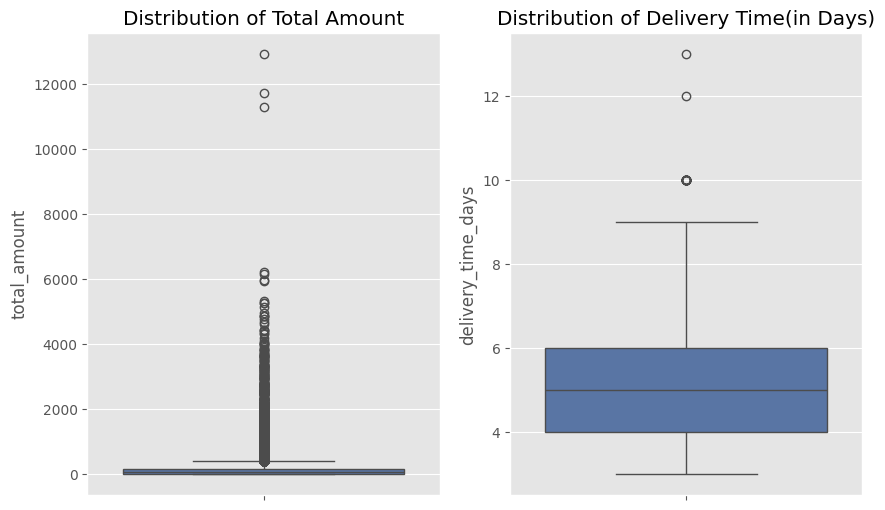

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxplot(data=df,y="total_amount")
plt.title("Distribution of Total Amount")

plt.subplot(1,2,2)
sns.boxplot(data=df,y="delivery_time_days")
plt.title("Distribution of Delivery Time(in Days)")

plt.show()

Distribution of Total Amount
(Insight)
-  Revenue generation appears to be influenced by a subset of high-value transactions, suggesting that premium purchases contribute disproportionately to overall sales performance.

Distribution of Delivery Time
(Insight)
- Operational performance appears generally consistent; however, delayed deliveries may represent opportunities for logistics optimization and customer experience improvements.

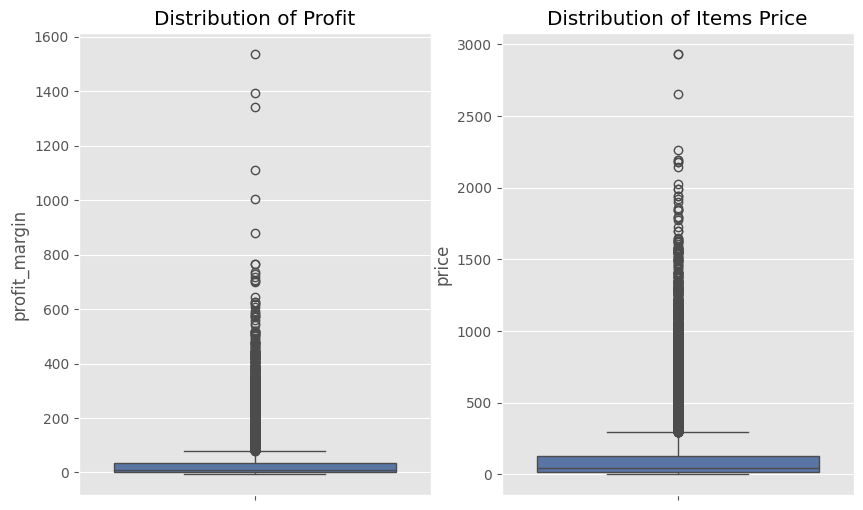

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxplot(data=df,y="profit_margin")
plt.title("Distribution of Profit")

plt.subplot(1,2,2)
sns.boxplot(data=df,y="price")
plt.title("Distribution of Items Price")

plt.show()

Distribution of Profit (Insight)
- Profit margins vary considerably across transactions, indicating differences in product profitability and pricing structures.

Distribution of Items Price (Insight)
- The business appears to serve multiple customer segments, with both value-oriented and premium-priced products contributing to sales activity.

### Categorical Analysis

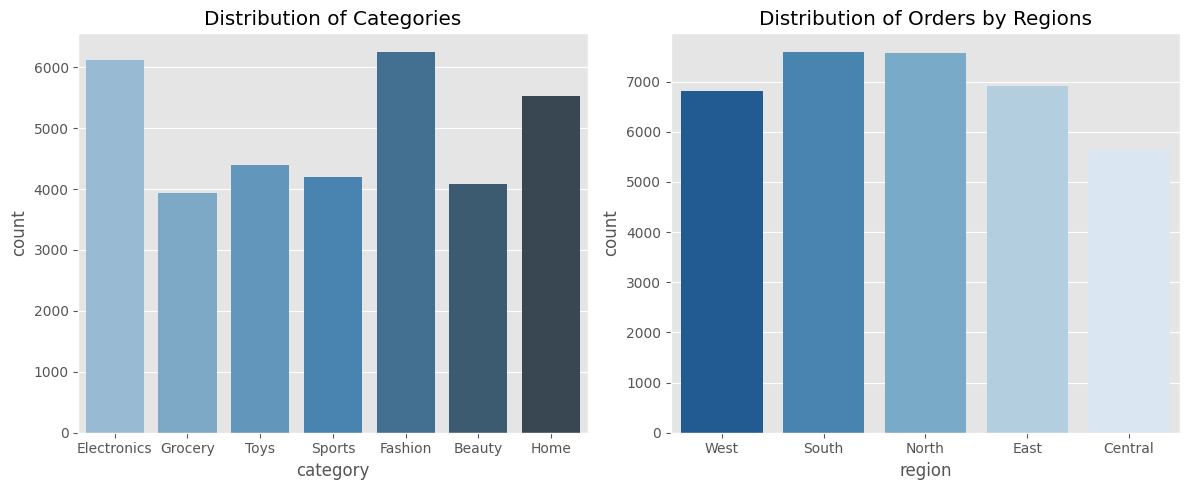

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x="category",palette="Blues_d")
plt.title("Distribution of Categories")

plt.subplot(1,2,2)
sns.countplot(data=df, x="region", palette ="Blues_r")
plt.title("Distribution of Orders by Regions")

plt.tight_layout()
plt.show()

Distribution of Categories (Insight)
- Sales activity is distributed across multiple product categories, with some categories recording noticeably higher transaction volumes.

Distribution of Orders by Regions
- Orders are distributed across all regions, indicating broad geographic coverage and market penetration.

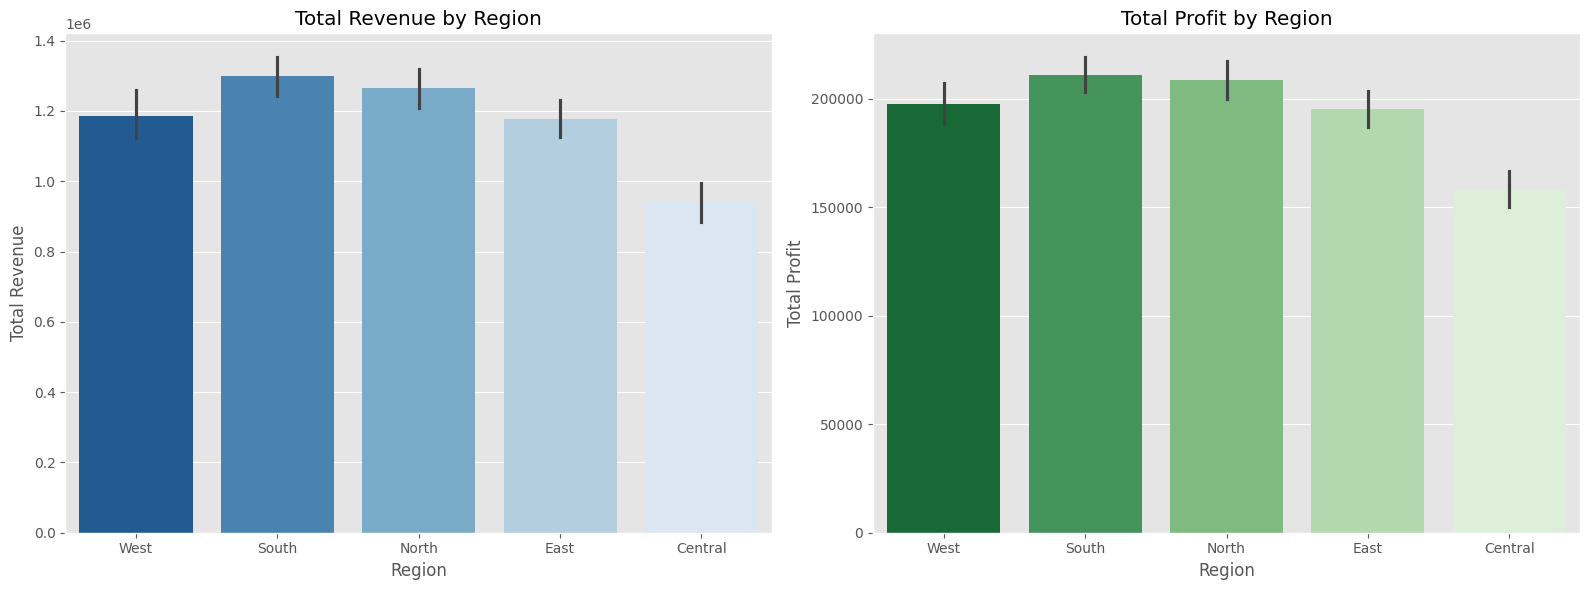

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='region', y='total_amount',estimator = sum ,palette='Blues_r')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='region', y='profit_margin', estimator = sum ,palette='Greens_r')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.show()


Total Revenue  and Profit by Regions (Insight)
- Both charts follow the exact same performance ranking, with the South leading and the Central region lagging at the bottom.
- Profit bars mimic revenue bars perfectly across all areas, indicating consistent profit margins regardless of region.

### Time Analysis

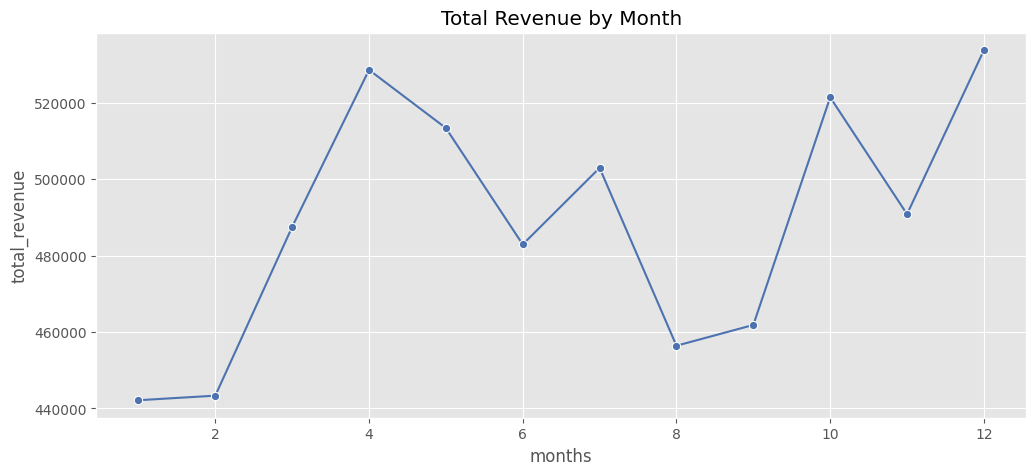

In [ ]:
totalrevenue = df.groupby("months")["total_amount"].sum().reset_index()
plt.figure(figsize=(12,5))

sns.lineplot(data=totalrevenue,x='months',y='total_amount',marker='o')

plt.title("Total Revenue by Month")
plt.ylabel("total_revenue")
plt.show()

Total Revenue by Month (Insight)
- Revenue levels fluctuate throughout the year, with certain months generating stronger financial performance than others.

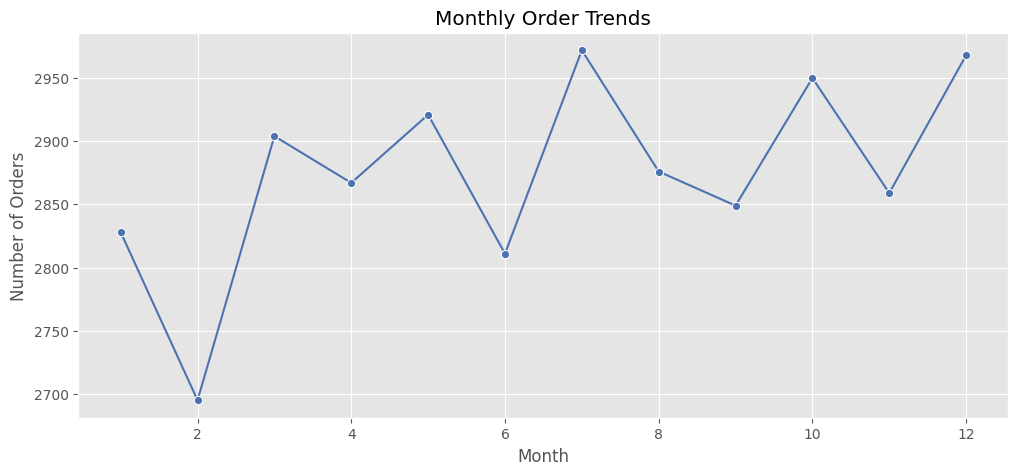

In [ ]:
plt.figure(figsize=(12, 5))

monthly_orders = df.groupby("months")["order_id"].nunique().reset_index(name="unique_orders")
sns.lineplot(data=monthly_orders, x='months', y='unique_orders', marker="o", errorbar=None)

plt.title("Monthly Order Trends")
plt.ylabel("Number of Orders")
plt.xlabel("Month")
plt.grid(True)
plt.show()

Monthly Orders Trends (Insight)
- Order volumes vary across months and generally follow similar patterns to revenue trends.

### Customer Analysis

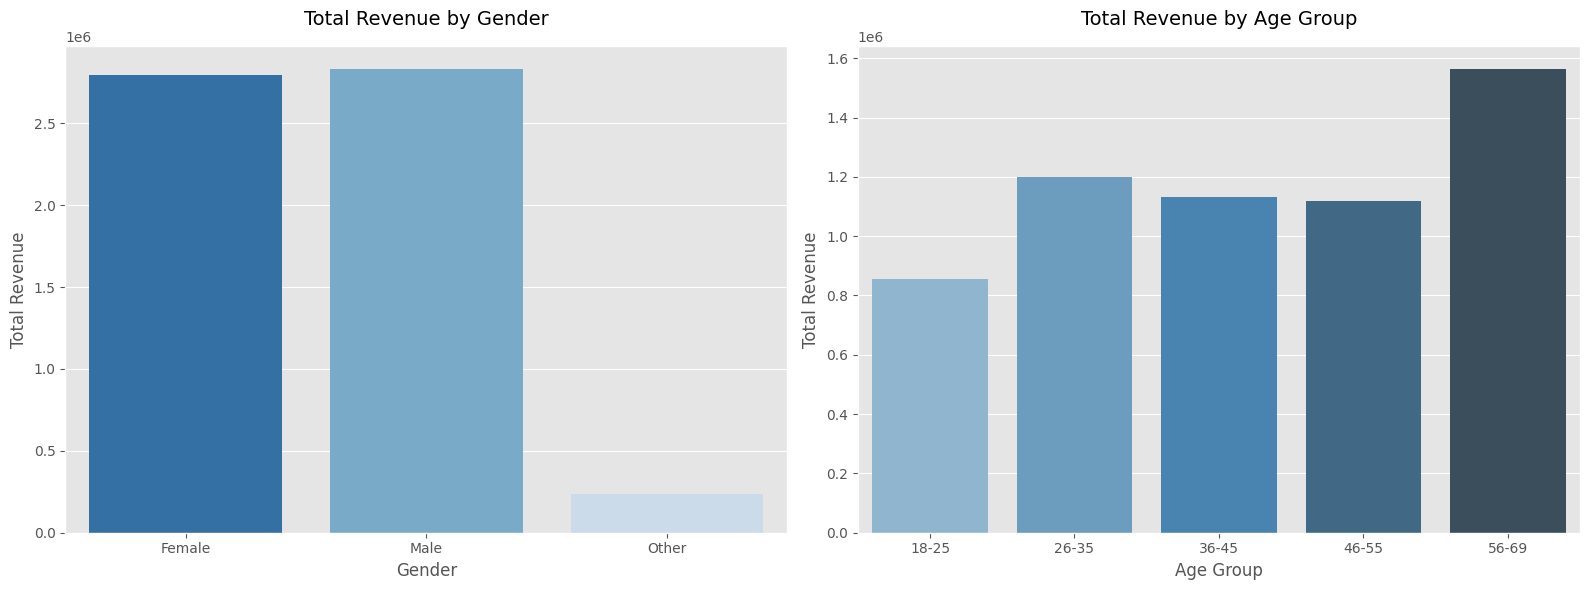

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)

gender_revenue = df.groupby("customer_gender")["total_amount"].sum().reset_index()

sns.barplot(data=gender_revenue, x="customer_gender", y="total_amount", palette="Blues_r")

plt.title("Total Revenue by Gender", fontsize=14, pad=15)
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.subplot(1, 2, 2)

age_revenue = df.groupby("age_group")["total_amount"].sum().reset_index()

sns.barplot(data=age_revenue, x="age_group", y="total_amount", palette="Blues_d")

plt.title("Total Revenue by Age Group", fontsize=14, pad=15)
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

Total Revenue by Gender (Insight)
- Revenue contribution differs across customer gender segments, indicating variations in purchasing behavior and spending patterns.

Total Revenue by Age Group (Insight)
- Revenue distribution varies across age groups, with certain demographic segments contributing a larger share of sales.

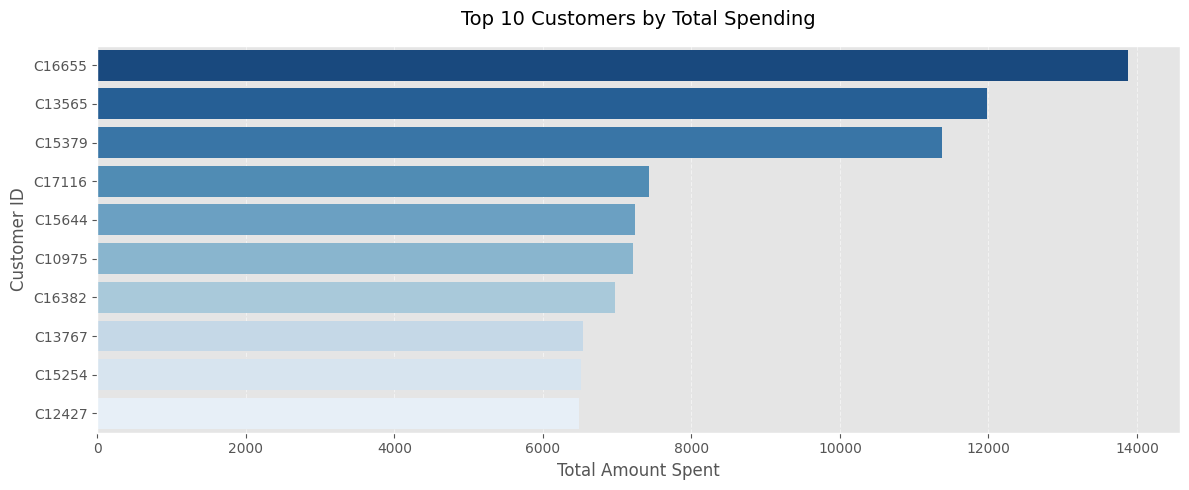

In [ ]:
plt.figure(figsize=(12,5))

topcustomer = df.groupby("customer_id")["total_amount"].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=topcustomer,x='total_amount',y='customer_id', palette="Blues_r" )
plt.title("Top 10 Customers by Total Spending", fontsize=14, pad=15)
plt.xlabel("Total Amount Spent")
plt.ylabel("Customer ID")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Top 10 Customers by Total Spending (Insight)
- A relatively small group of customers contributes a significant share of total revenue compared with the broader customer base.

### Product Analysis

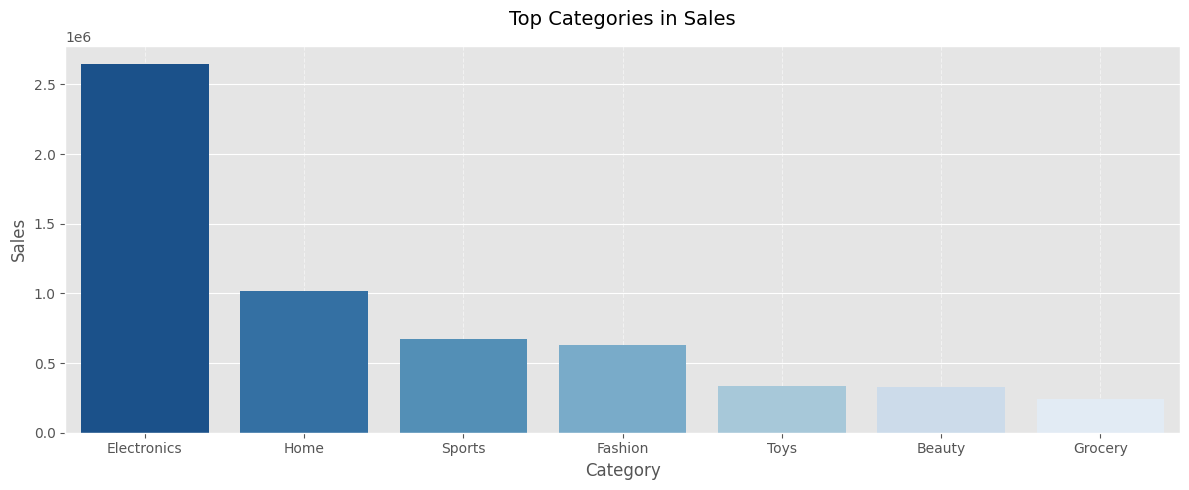

In [ ]:
plt.figure(figsize=(12,5))

topcategories = df.groupby("category")["total_amount"].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=topcategories,x='category',y='total_amount', palette="Blues_r")
plt.title("Top Categories in Sales", fontsize=14, pad=15)
plt.xlabel("Category")
plt.ylabel("Sales")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Top Categories in Sales (Insight)
- Electronics dominates total revenue. This high dependency on a single category presents a business risk; sales should ideally be more evenly distributed.

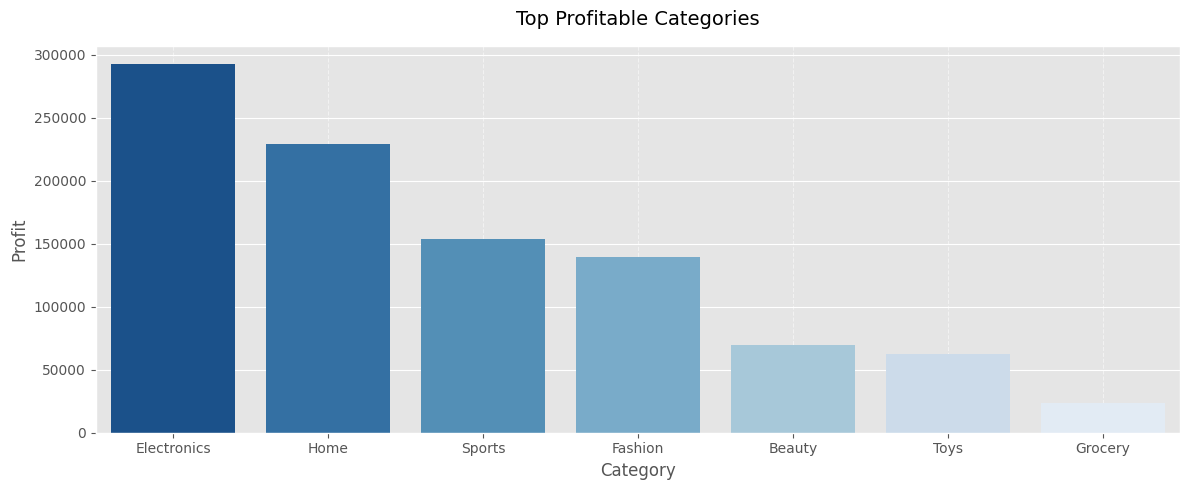

In [ ]:
plt.figure(figsize=(12,5))

profitablecategories = df.groupby("category")["profit_margin"].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=profitablecategories,x='category',y='profit_margin', palette="Blues_r")
plt.title("Top Profitable Categories", fontsize=14, pad=15)
plt.xlabel("Category")
plt.ylabel("Profit")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Top Profitable Categories (Insight)
- While Electronics still leads total profit, other categories show higher profit margins and stronger growth potential compared to their revenue shares.

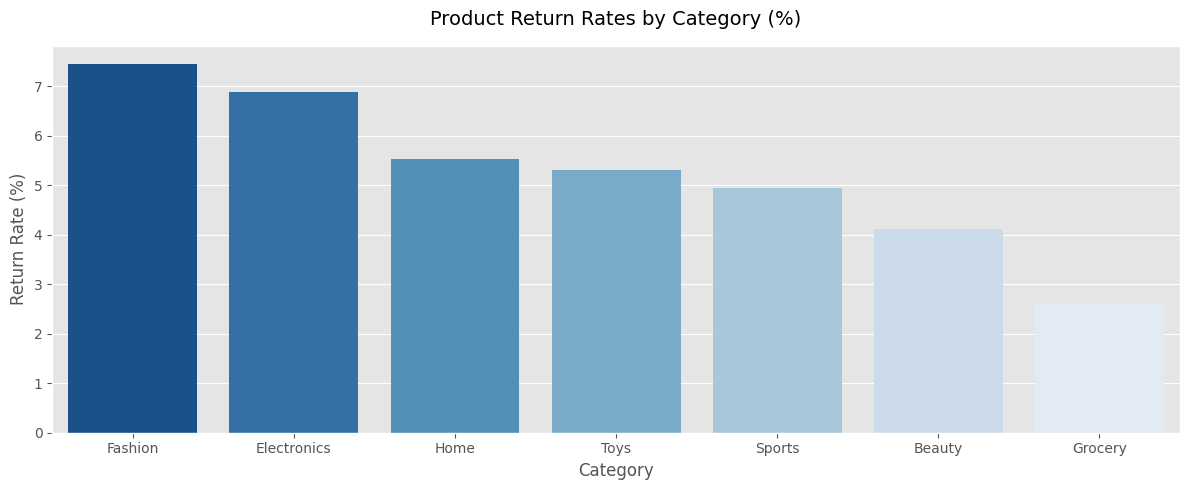

In [ ]:
plt.figure(figsize=(12, 5))

df["is_returned"] = df["returned"].map({"Yes": 1, "No": 0})

return_rates= df.groupby("category")["is_returned"].mean().sort_values(ascending = False).reset_index(name = "return_rate_pct")
return_rates["return_rate_pct"] = return_rates["return_rate_pct"] * 100

sns.barplot(data=return_rates, x="category", y="return_rate_pct", palette="Blues_r")

plt.title("Product Return Rates by Category (%)", fontsize=14, pad=15)
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

Product Return Rates by Category (%) (Insight)

- Categories with elevated return rates represent potential risks to profitability and customer experience. Further investigation into return drivers is recommended.

### Correlation Analysis

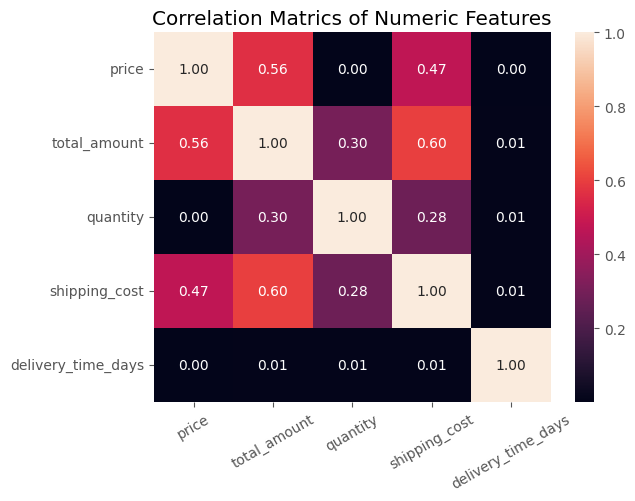

In [ ]:
label = df[["price","total_amount","quantity","shipping_cost","delivery_time_days"]]
corr_data= label.corr()

sns.heatmap(corr_data, annot= True,fmt=".2f")

plt.xticks(rotation=30)
plt.title("Correlation Matrics of Numeric Features")
plt.show()


Correlation Analysis (Insight)
- Product pricing appears to be the primary factor influencing transaction value, while delivery performance does not exhibit a strong direct relationship with spending behavior within this dataset.

### Business KPI Analysis

In [ ]:
# 1. Build the base summary table
kpi_dashboard = df.groupby('region').agg(
    total_revenue=('total_amount', 'sum'),
    total_orders=('order_id', 'nunique'),          # Counts unique order numbers
    total_returns=('is_returned', 'sum'),          # Counts orders where returned == 1
    avg_delivery_time=('delivery_time_days', 'mean')  # Simple average for delivery duration
)

# 2. Compute the Derived KPIs accurately
kpi_dashboard['average_order_value'] = kpi_dashboard['total_revenue'] / kpi_dashboard['total_orders']
kpi_dashboard['return_rate'] = (kpi_dashboard['total_returns'] / kpi_dashboard['total_orders']) * 100

kpi_dashboard = kpi_dashboard.sort_values(by='total_revenue', ascending=False)


# 3. Clean up raw columns used for math and reorder for presentation
kpi_dashboard = kpi_dashboard[['total_revenue', 'total_orders', 'average_order_value', 'return_rate', 'avg_delivery_time']]

# Display beautifully inside the notebook
kpi_dashboard.style.format({
    'total revenue': '${:,.2f}',
    'total_orders': '{:,}',
    'average_order_value': '${:,.2f}',
    'return_rate': '{:.2f}%',
    'avg_delivery_time': '{:.1f} days'
})

,total_revenue,total_orders,average_order_value,return_rate,avg_delivery_time
region,,,,,
South,1298096.070000,"7,584",$171.16,5.68%,5.0 days
North,1264008.350000,"7,572",$166.93,5.36%,4.0 days
West,1186350.500000,"6,808",$174.26,5.45%,5.0 days
East,1176334.750000,"6,904",$170.38,5.91%,6.0 days
Central,940503.380000,"5,632",$166.99,5.10%,4.0 days


# Final EDA Summary
### Executive Summary
- Revenue and order activity show noticeable variation across months, indicating seasonal demand patterns.
- Customer spending is concentrated among a relatively small group of high-value customers.
- Product categories differ significantly in both revenue generation and profitability.
- Return rates vary across categories, creating opportunities for operational and product-level improvements.
- Price is the strongest driver of transaction value, while delivery time demonstrates limited influence on purchasing behavior.
- Data quality issues were identified and corrected before analysis, improving confidence in subsequent findings.